## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 1
#### ***Part B: Convolutional Neural Network***

**Loading and Normalizing CIFAR-10 dataset:**

In [8]:
import time
from keras import layers, models
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from dataProccessing import load_cifar10, get_class_names
from convolutionalNeuralNetwork import cnn_plots, cnn_results, cnn_per_class_accuracy
from convolutionalNeuralNetwork import data_augmentation, sparse_cce_label_smoothing


# Load class names
class_names = get_class_names()

# Load and normalize CIFAR-10 dataset
x_train, y_train, x_test, y_test = load_cifar10()

# Ensure data is in the correct shape for CNN
x_train = x_train.reshape((-1, 32, 32, 3))
x_test = x_test.reshape((-1, 32, 32, 3))

CIFAR-10 Classes
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck

Loading and Normalizing CIFAR-10
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


##### ***Model 1***
Base CNN model with 9 layers trained for 10 epochs.

In [3]:
# Build the 1st CNN model
model_1 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Train the model
start_time = time.time()
history_1 = model_1.fit(x_train, y_train, epochs=10, batch_size=64, verbose=2,
            validation_split=0.2)
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_1.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 - 13s - 21ms/step - accuracy: 0.3044 - loss: 1.8662 - val_accuracy: 0.4631 - val_loss: 1.5103
Epoch 2/10
625/625 - 11s - 17ms/step - accuracy: 0.4419 - loss: 1.5265 - val_accuracy: 0.5493 - val_loss: 1.2784
Epoch 3/10
625/625 - 11s - 17ms/step - accuracy: 0.5008 - loss: 1.3656 - val_accuracy: 0.6121 - val_loss: 1.1121
Epoch 4/10
625/625 - 12s - 19ms/step - accuracy: 0.5492 - loss: 1.2476 - val_accuracy: 0.6453 - val_loss: 1.0294
Epoch 5/10
625/625 - 12s - 19ms/step - accuracy: 0.5819 - loss: 1.1733 - val_accuracy: 0.6302 - val_loss: 1.0530
Epoch 6/10
625/625 - 12s - 19ms/step - accuracy: 0.6075 - loss: 1.0938 - val_accuracy: 0.6692 - val_loss: 0.9523
Epoch 7/10
625/625 - 12s - 19ms/step - accuracy: 0.6281 - loss: 1.0357 - val_accuracy: 0.6896 - val_loss: 0.8783
Epoch 8/10
625/625 - 12s - 20ms/step - accuracy: 0.6496 - loss: 0.9753 - val_accuracy: 0.6981 - val_loss: 0.8708
Epoch 9/10
625/625 - 12s - 20ms/step - accuracy: 0.6655 - loss: 0.9335 - val_accuracy: 0.7066 - 

**Plot learning curves:**

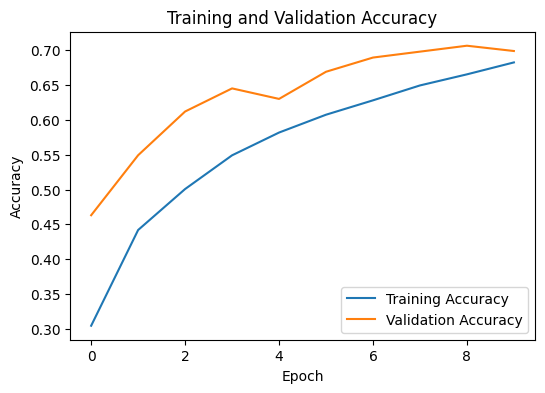

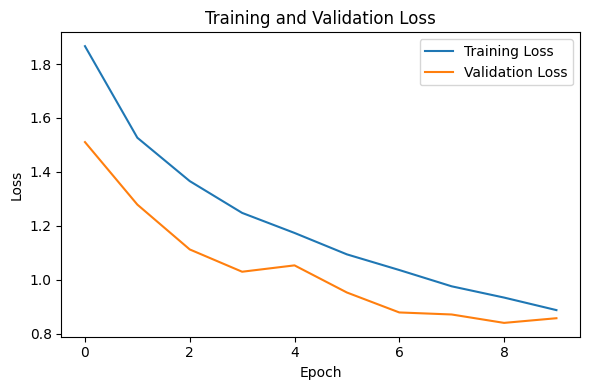

In [18]:
# Visualizations for the 1st model
cnn_plots(history_1)

##### ***Model 2***
Adding more layers, still training for 10 epochs.

In [26]:
# Build the 2nd CNN model
model_2 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Train the model
start_time = time.time()
history_2 = model_2.fit(x_train, y_train, epochs=10, batch_size=64, verbose=2,
            validation_split=0.2)
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_2.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Epoch 1/10
625/625 - 25s - 40ms/step - accuracy: 0.3590 - loss: 1.7215 - val_accuracy: 0.5235 - val_loss: 1.3288
Epoch 2/10
625/625 - 15s - 24ms/step - accuracy: 0.5143 - loss: 1.3527 - val_accuracy: 0.5880 - val_loss: 1.1449
Epoch 3/10
625/625 - 15s - 24ms/step - accuracy: 0.5830 - loss: 1.1738 - val_accuracy: 0.6403 - val_loss: 1.0143
Epoch 4/10
625/625 - 21s - 34ms/step - accuracy: 0.6306 - loss: 1.0569 - val_accuracy: 0.6911 - val_loss: 0.8990
Epoch 5/10
625/625 - 18s - 28ms/step - accuracy: 0.6623 - loss: 0.9642 - val_accuracy: 0.7042 - val_loss: 0.8541
Epoch 6/10
625/625 - 16s - 25ms/step - accuracy: 0.6926 - loss: 0.8817 - val_accuracy: 0.7023 - val_loss: 0.8452
Epoch 7/10
625/625 - 16s - 25ms/step - accuracy: 0.7099 - loss: 0.8247 - val_accuracy: 0.7240 - val_loss: 0.7966
Epoch 8/10
625/625 - 17s - 27ms/step - accuracy: 0.7316 - loss: 0.7641 - val_accuracy: 0.7264 - val_loss: 0.7883
Epoch 9/10
625/625 - 17s - 28ms/step - accuracy: 0.7496 - loss: 0.7097 - val_accuracy: 0.7368 - 

**Plot learning curves:**

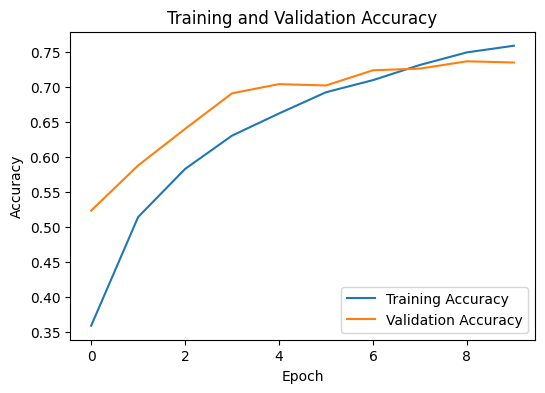

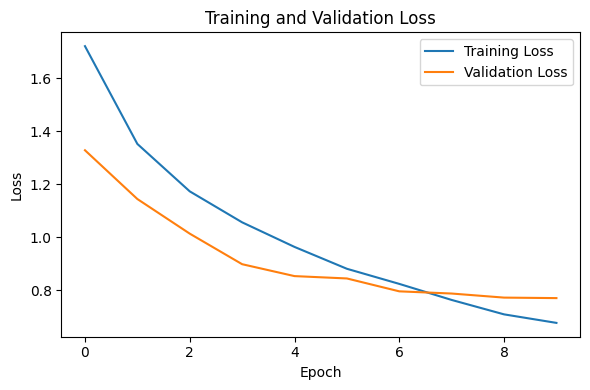

In [27]:
# Visualizations for the 2nd model
cnn_plots(history_2)

##### ***Model 3***
Adding Batch Normalization, increasing Dropout layers and training for 20 epochs.

In [5]:
# Build the 3rd CNN model
model_3 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_3.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Train the model
start_time = time.time()
history_3 = model_3.fit(x_train, y_train, epochs=20, batch_size=64, verbose=2,
            validation_split=0.2)
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_3.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Epoch 1/20
625/625 - 38s - 61ms/step - accuracy: 0.3857 - loss: 1.8234 - val_accuracy: 0.4192 - val_loss: 1.6163
Epoch 2/20
625/625 - 30s - 49ms/step - accuracy: 0.5323 - loss: 1.3036 - val_accuracy: 0.5663 - val_loss: 1.2185
Epoch 3/20
625/625 - 32s - 51ms/step - accuracy: 0.5952 - loss: 1.1384 - val_accuracy: 0.6480 - val_loss: 1.0054
Epoch 4/20
625/625 - 31s - 50ms/step - accuracy: 0.6358 - loss: 1.0376 - val_accuracy: 0.6506 - val_loss: 0.9773
Epoch 5/20
625/625 - 32s - 51ms/step - accuracy: 0.6568 - loss: 0.9768 - val_accuracy: 0.6880 - val_loss: 0.8920
Epoch 6/20
625/625 - 33s - 52ms/step - accuracy: 0.6779 - loss: 0.9233 - val_accuracy: 0.7184 - val_loss: 0.8099
Epoch 7/20
625/625 - 37s - 59ms/step - accuracy: 0.6906 - loss: 0.8862 - val_accuracy: 0.7112 - val_loss: 0.8266
Epoch 8/20
625/625 - 38s - 61ms/step - accuracy: 0.7018 - loss: 0.8506 - val_accuracy: 0.7163 - val_loss: 0.8311
Epoch 9/20
625/625 - 32s - 51ms/step - accuracy: 0.7148 - loss: 0.8138 - val_accuracy: 0.6911 - 

**Plot learning curves:**

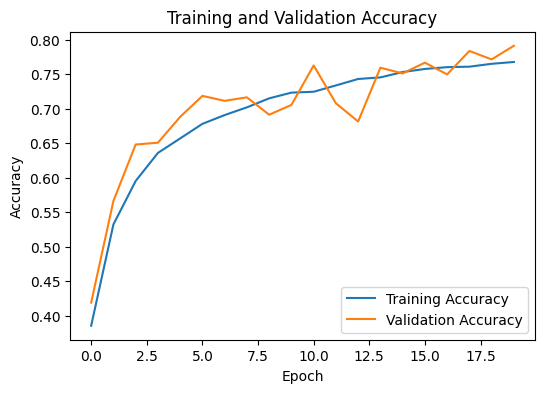

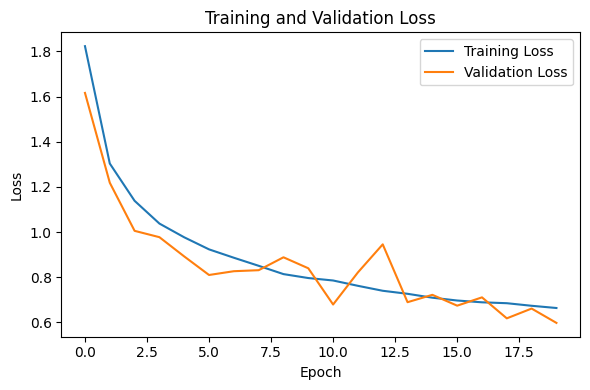

In [20]:
# Visualizations for the 3rd model
cnn_plots(history_3)

##### ***Model 4***
Introducing Data Augmentation, training for 20 epochs.

In [9]:
# Build the 4th CNN model
model_4 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_4.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Split training data into train and validation sets
x_train_4, x_val_4, y_train_4, y_val_4 = train_test_split(x_train, y_train, test_size=0.2, 
                                                          random_state=42, stratify=y_train)

# Create augmented data generator
print("Creating data augmentation...")
train_datagen = data_augmentation()
train_datagen.fit(x_train_4)

# For validation, use a generator with no augmentation
val_datagen = ImageDataGenerator()
val_datagen.fit(x_val_4)

# Train the model
start_time = time.time()
history_4 = model_4.fit(train_datagen.flow(x_train_4, y_train_4, batch_size=64), epochs=20, verbose=2,
                        validation_data=val_datagen.flow(x_val_4, y_val_4, batch_size=64))
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_4.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Creating data augmentation...
Epoch 1/20
625/625 - 40s - 64ms/step - accuracy: 0.3566 - loss: 1.9074 - val_accuracy: 0.4714 - val_loss: 1.4828
Epoch 2/20
625/625 - 34s - 55ms/step - accuracy: 0.4757 - loss: 1.4481 - val_accuracy: 0.5929 - val_loss: 1.1415
Epoch 3/20
625/625 - 35s - 56ms/step - accuracy: 0.5296 - loss: 1.3177 - val_accuracy: 0.4754 - val_loss: 1.5145
Epoch 4/20
625/625 - 36s - 58ms/step - accuracy: 0.5589 - loss: 1.2280 - val_accuracy: 0.5614 - val_loss: 1.2585
Epoch 5/20
625/625 - 35s - 56ms/step - accuracy: 0.5860 - loss: 1.1734 - val_accuracy: 0.6181 - val_loss: 1.0894
Epoch 6/20
625/625 - 35s - 56ms/step - accuracy: 0.6042 - loss: 1.1256 - val_accuracy: 0.5563 - val_loss: 1.3109
Epoch 7/20
625/625 - 37s - 59ms/step - accuracy: 0.6153 - loss: 1.0991 - val_accuracy: 0.6436 - val_loss: 1.0362
Epoch 8/20
625/625 - 42s - 68ms/step - accuracy: 0.6223 - loss: 1.0658 - val_accuracy: 0.6281 - val_loss: 1.1021
Epoch 9/20
625/625 - 43s - 69ms/step - accuracy: 0.6366 - loss: 1.

**Plot learning curves:**

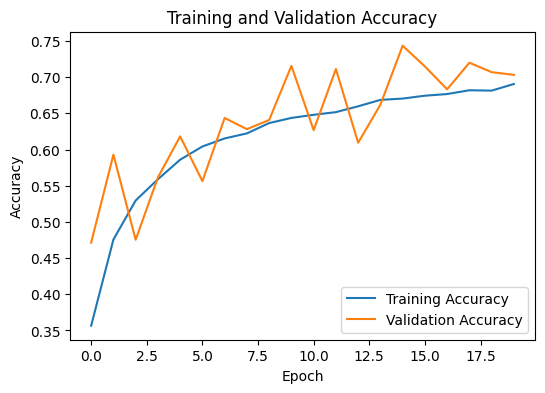

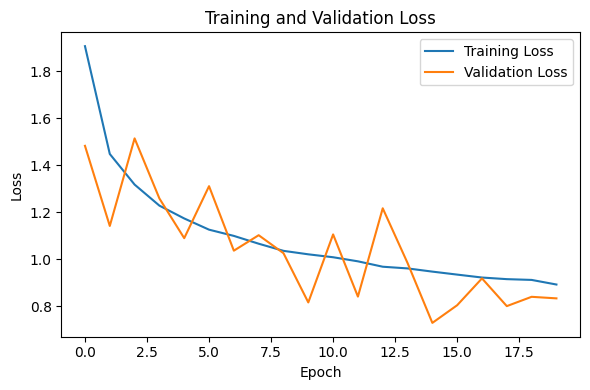

In [21]:
# Visualizations for the 4th model
cnn_plots(history_4)

##### ***Model 5***
Decreasing Dropout layers, training for 30 epochs.

In [10]:
# Build the 5th CNN model
model_5 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_5.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Split training data into train and validation sets
x_train_5, x_val_5, y_train_5, y_val_5 = train_test_split(x_train, y_train, test_size=0.2, 
                                                          random_state=42, stratify=y_train)

# Create augmented data generator
print("Creating data augmentation...")
train_datagen = data_augmentation()
train_datagen.fit(x_train_5)

# For validation, use a generator with no augmentation
val_datagen = ImageDataGenerator()
val_datagen.fit(x_val_5)

# Train the model
start_time = time.time()
history_5 = model_5.fit(train_datagen.flow(x_train_5, y_train_5, batch_size=64), epochs=30, verbose=2,
                        validation_data=val_datagen.flow(x_val_5, y_val_5, batch_size=64))
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_5.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Creating data augmentation...
Epoch 1/30
625/625 - 37s - 59ms/step - accuracy: 0.4604 - loss: 1.5358 - val_accuracy: 0.5324 - val_loss: 1.3073
Epoch 2/30
625/625 - 35s - 56ms/step - accuracy: 0.5942 - loss: 1.1469 - val_accuracy: 0.6271 - val_loss: 1.0900
Epoch 3/30
625/625 - 34s - 55ms/step - accuracy: 0.6384 - loss: 1.0196 - val_accuracy: 0.6683 - val_loss: 0.9414
Epoch 4/30
625/625 - 35s - 56ms/step - accuracy: 0.6714 - loss: 0.9395 - val_accuracy: 0.6790 - val_loss: 0.9233
Epoch 5/30
625/625 - 36s - 57ms/step - accuracy: 0.6891 - loss: 0.8798 - val_accuracy: 0.7251 - val_loss: 0.7863
Epoch 6/30
625/625 - 36s - 57ms/step - accuracy: 0.7090 - loss: 0.8302 - val_accuracy: 0.6397 - val_loss: 1.0809
Epoch 7/30
625/625 - 36s - 58ms/step - accuracy: 0.7208 - loss: 0.8003 - val_accuracy: 0.6719 - val_loss: 0.9859
Epoch 8/30
625/625 - 36s - 57ms/step - accuracy: 0.7308 - loss: 0.7655 - val_accuracy: 0.7136 - val_loss: 0.8218
Epoch 9/30
625/625 - 35s - 56ms/step - accuracy: 0.7418 - loss: 0.

**Plot learning curves:**

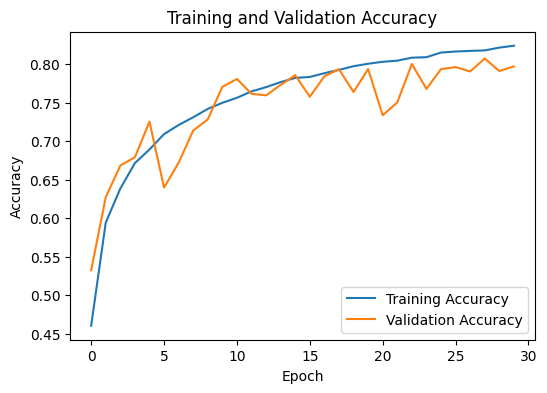

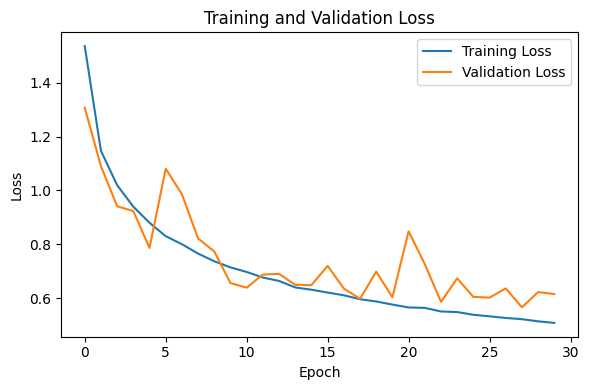

In [22]:
# Visualizations for the 5th model
cnn_plots(history_5)

##### ***Model 6***
Increasing epochs to 50, but using Early Stopping

In [11]:
# Build the 6th CNN model
model_6 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_6.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Split training data into train and validation sets
x_train_6, x_val_6, y_train_6, y_val_6 = train_test_split(x_train, y_train, test_size=0.2, 
                                                          random_state=42, stratify=y_train)

# Create augmented data generator
print("Creating data augmentation...")
train_datagen = data_augmentation()
train_datagen.fit(x_train_6)

# For validation, use a generator with no augmentation
val_datagen = ImageDataGenerator()
val_datagen.fit(x_val_6)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, 
                           restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint('best_model_6.keras', monitor='val_loss',
                             save_best_only=True, verbose=1)

# Train the model
start_time = time.time()
history_6 = model_6.fit(train_datagen.flow(x_train_6, y_train_6, batch_size=64), epochs=50, verbose=2,
                        validation_data=val_datagen.flow(x_val_6, y_val_6, batch_size=64), callbacks=[early_stop, checkpoint])
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_6.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Creating data augmentation...
Epoch 1/50

Epoch 1: val_loss improved from None to 1.14326, saving model to best_model_6.keras
625/625 - 43s - 69ms/step - accuracy: 0.4656 - loss: 1.5214 - val_accuracy: 0.5940 - val_loss: 1.1433
Epoch 2/50

Epoch 2: val_loss did not improve from 1.14326
625/625 - 43s - 68ms/step - accuracy: 0.5917 - loss: 1.1457 - val_accuracy: 0.5719 - val_loss: 1.3313
Epoch 3/50

Epoch 3: val_loss did not improve from 1.14326
625/625 - 46s - 73ms/step - accuracy: 0.6390 - loss: 1.0234 - val_accuracy: 0.5297 - val_loss: 1.3474
Epoch 4/50

Epoch 4: val_loss did not improve from 1.14326
625/625 - 44s - 71ms/step - accuracy: 0.6709 - loss: 0.9441 - val_accuracy: 0.6001 - val_loss: 1.1870
Epoch 5/50

Epoch 5: val_loss improved from 1.14326 to 1.12774, saving model to best_model_6.keras
625/625 - 42s - 67ms/step - accuracy: 0.6913 - loss: 0.8837 - val_accuracy: 0.6423 - val_loss: 1.1277
Epoch 6/50

Epoch 6: val_loss improved from 1.12774 to 0.86844, saving model to best_mod

**Plot learning curves:**

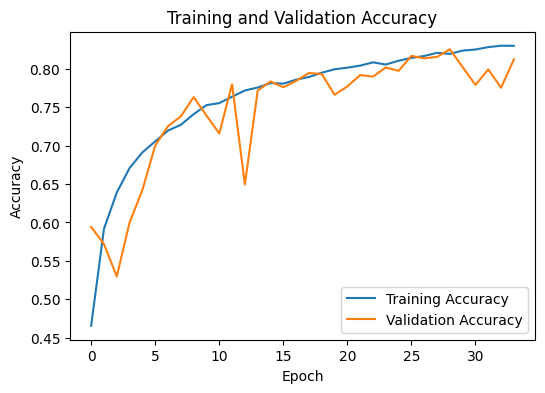

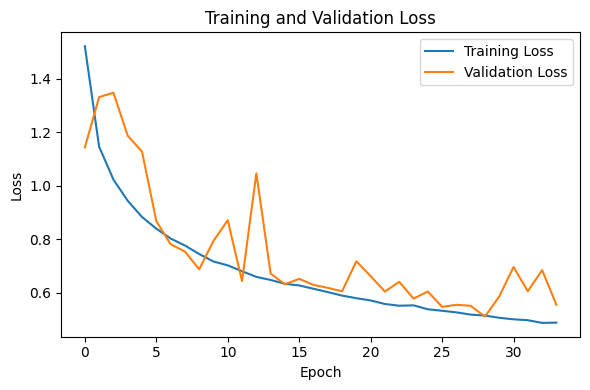

In [23]:
# Visualizations for the 6th model
cnn_plots(history_6)

##### ***Model 7***
Automatically reducing optimizer’s learning rate when validation loss stops improving, training for 50 epochs.

In [12]:
# Build the 7th CNN model
model_7 = models.Sequential([
    # Block 1: 32 filters   
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_7.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Split training data into train and validation sets
x_train_7, x_val_7, y_train_7, y_val_7 = train_test_split(x_train, y_train, test_size=0.2, 
                                                          random_state=42, stratify=y_train)

# Create augmented data generator
print("Creating data augmentation...")
train_datagen = data_augmentation()
train_datagen.fit(x_train_7)

# For validation, use a generator with no augmentation
val_datagen = ImageDataGenerator()
val_datagen.fit(x_val_7)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, 
                           restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint('best_model_7.keras', monitor='val_loss',
                             save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                min_lr=1e-6, verbose=1)

# Train the model
start_time = time.time()
history_7 = model_7.fit(train_datagen.flow(x_train_7, y_train_7, batch_size=64), epochs=50, verbose=2,
                        validation_data=val_datagen.flow(x_val_7, y_val_7, batch_size=64), callbacks=[early_stop, checkpoint, reduce_lr])
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_7.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")


c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Creating data augmentation...
Epoch 1/50

Epoch 1: val_loss improved from None to 1.24097, saving model to best_model_7.keras
625/625 - 46s - 74ms/step - accuracy: 0.4657 - loss: 1.5377 - val_accuracy: 0.5556 - val_loss: 1.2410 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.24097 to 1.12078, saving model to best_model_7.keras
625/625 - 38s - 61ms/step - accuracy: 0.5964 - loss: 1.1454 - val_accuracy: 0.6157 - val_loss: 1.1208 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 1.12078 to 1.05739, saving model to best_model_7.keras
625/625 - 38s - 61ms/step - accuracy: 0.6464 - loss: 1.0045 - val_accuracy: 0.6441 - val_loss: 1.0574 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss improved from 1.05739 to 0.98161, saving model to best_model_7.keras
625/625 - 38s - 61ms/step - accuracy: 0.6772 - loss: 0.9239 - val_accuracy: 0.6761 - val_loss: 0.9816 - learning_rate: 0.0010
Epoch 5/50

Epoch 5: val_loss improved from 0.98161 to 0.89660, saving mo

**Plot learning curves:**

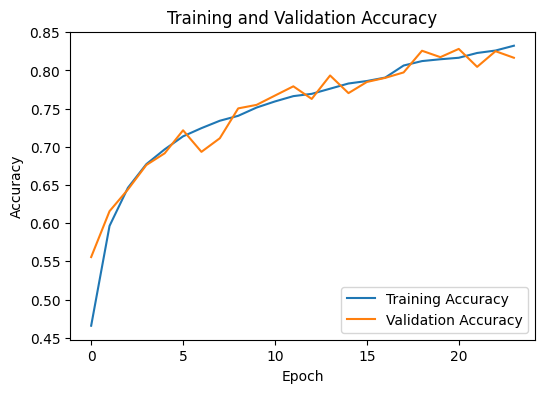

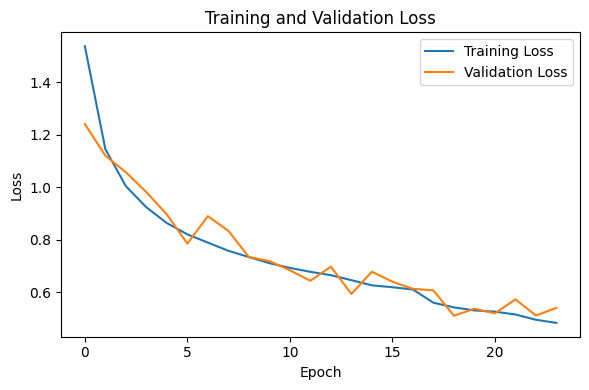

In [24]:
# Visualizations for the 7th model
cnn_plots(history_7)

##### ***Model 8***
Making the model deeper and using GlobalAveragePooling2D, training for 80 epochs.

In [13]:
# Build the 8th CNN model
model_8 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4: 256 filters
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),    # Replaces Flatten for better generalization

    # Fully connected layers
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_8.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Split training data into train and validation sets
x_train_8, x_val_8, y_train_8, y_val_8 = train_test_split(x_train, y_train, test_size=0.2, 
                                                          random_state=42, stratify=y_train)

# Create augmented data generator
print("Creating data augmentation...")
train_datagen = data_augmentation()
train_datagen.fit(x_train_8)

# For validation, use a generator with no augmentation
val_datagen = ImageDataGenerator()
val_datagen.fit(x_val_8)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, 
                           restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint('best_model_8.keras', monitor='val_loss',
                             save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                min_lr=1e-6, verbose=1)

# Train the model
start_time = time.time()
history_8 = model_8.fit(train_datagen.flow(x_train_8, y_train_8, batch_size=64), epochs=80, verbose=2,
                        validation_data=val_datagen.flow(x_val_8, y_val_8, batch_size=64), callbacks=[early_stop, checkpoint, reduce_lr])
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_8.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Creating data augmentation...
Epoch 1/80

Epoch 1: val_loss improved from None to 1.69559, saving model to best_model_8.keras
625/625 - 101s - 161ms/step - accuracy: 0.4372 - loss: 1.5949 - val_accuracy: 0.4550 - val_loss: 1.6956 - learning_rate: 0.0010
Epoch 2/80

Epoch 2: val_loss improved from 1.69559 to 0.94948, saving model to best_model_8.keras
625/625 - 90s - 143ms/step - accuracy: 0.6215 - loss: 1.0730 - val_accuracy: 0.6674 - val_loss: 0.9495 - learning_rate: 0.0010
Epoch 3/80

Epoch 3: val_loss improved from 0.94948 to 0.91732, saving model to best_model_8.keras
625/625 - 95s - 152ms/step - accuracy: 0.6950 - loss: 0.8764 - val_accuracy: 0.6845 - val_loss: 0.9173 - learning_rate: 0.0010
Epoch 4/80

Epoch 4: val_loss improved from 0.91732 to 0.78739, saving model to best_model_8.keras
625/625 - 95s - 151ms/step - accuracy: 0.7358 - loss: 0.7735 - val_accuracy: 0.7344 - val_loss: 0.7874 - learning_rate: 0.0010
Epoch 5/80

Epoch 5: val_loss improved from 0.78739 to 0.74406, savi

**Plot learning curves:**

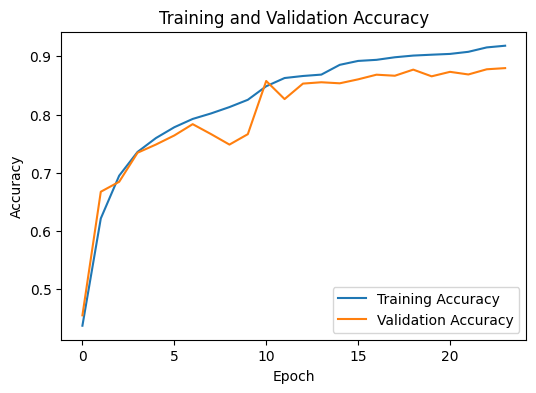

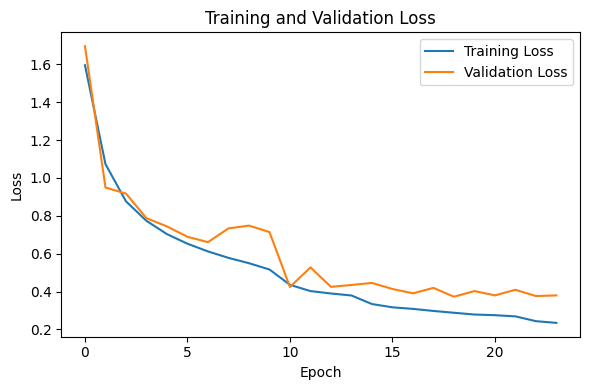

In [29]:
# Visualizations for the 8th model
cnn_plots(history_8)

##### ***Model 9***
Increasing Dropout and training for 50 epochs.

In [ ]:
# Build the 9th CNN model
model_9 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4: 256 filters
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.GlobalAveragePooling2D(),    # Replaces Flatten for better generalization

    # Fully connected layers
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model_9.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Split training data into train and validation sets
x_train_9, x_val_9, y_train_9, y_val_9 = train_test_split(x_train, y_train, test_size=0.2, 
                                                          random_state=42, stratify=y_train)

# Create augmented data generator
print("Creating data augmentation...")
train_datagen = data_augmentation()
train_datagen.fit(x_train_9)

# For validation, use a generator with no augmentation
val_datagen = ImageDataGenerator()
val_datagen.fit(x_val_9)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, 
                           restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint('best_model_9.keras', monitor='val_loss',
                             save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                min_lr=1e-6, verbose=1)

# Train the model
start_time = time.time()
history_9 = model_9.fit(train_datagen.flow(x_train_9, y_train_9, batch_size=64), epochs=50, verbose=2,
                        validation_data=val_datagen.flow(x_val_9, y_val_9, batch_size=64), callbacks=[early_stop, checkpoint, reduce_lr])
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_9.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Creating data augmentation...
Epoch 1/50

Epoch 1: val_loss improved from None to 1.20194, saving model to best_model_10.keras
625/625 - 144s - 230ms/step - accuracy: 0.4481 - loss: 1.6052 - val_accuracy: 0.5767 - val_loss: 1.2019 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.20194 to 0.95029, saving model to best_model_10.keras
625/625 - 92s - 148ms/step - accuracy: 0.6232 - loss: 1.0768 - val_accuracy: 0.6590 - val_loss: 0.9503 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss did not improve from 0.95029
625/625 - 89s - 143ms/step - accuracy: 0.6906 - loss: 0.8910 - val_accuracy: 0.6491 - val_loss: 1.1356 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss did not improve from 0.95029
625/625 - 94s - 150ms/step - accuracy: 0.7286 - loss: 0.7871 - val_accuracy: 0.6269 - val_loss: 1.3014 - learning_rate: 0.0010
Epoch 5/50

Epoch 5: val_loss improved from 0.95029 to 0.77285, saving model to best_model_10.keras
625/625 - 93s - 150ms/step - accuracy: 0.7555 

**Plot learning curves:**

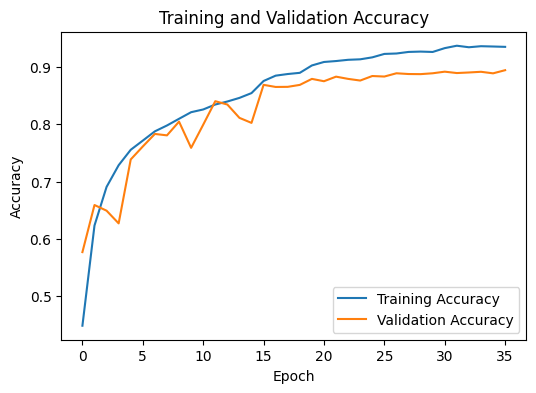

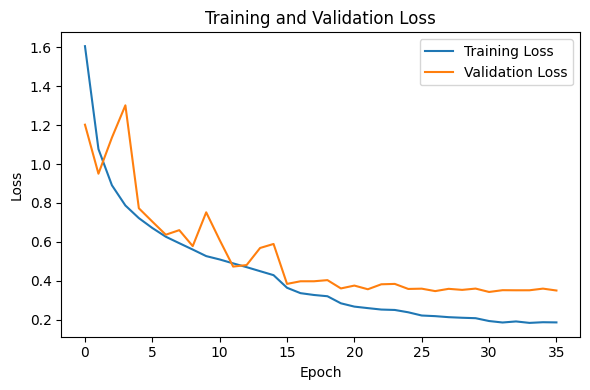

In [ ]:
# Visualizations for the 9th model
cnn_plots(history_9)

##### ***Model 10***
Using custom function for Categorical Cross-entropy Loss with Label Smoothing, training for 80 epochs.

In [ ]:
# Build the 10th CNN model
model_10 = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4: 256 filters
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Global Average Pooling layer 
    layers.GlobalAveragePooling2D(),

    # Fully connected layers
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_10.compile(
    optimizer='adam',
    loss=sparse_cce_label_smoothing,
    metrics=['accuracy']
)

# Split training data into train and validation sets
x_train_10, x_val_10, y_train_10, y_val_10 = train_test_split(x_train, y_train, test_size=0.2, 
                                                          random_state=42, stratify=y_train)

# Create augmented data generator
print("Creating data augmentation...")
train_datagen = data_augmentation()
train_datagen.fit(x_train_10)

# For validation, use a generator with no augmentation
val_datagen = ImageDataGenerator()
val_datagen.fit(x_val_10)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, 
                           restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint('best_model_10.keras', monitor='val_loss',
                             save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                min_lr=1e-6, verbose=1)

# Train the model
start_time = time.time()
history_10 = model_10.fit(train_datagen.flow(x_train_10, y_train_10, batch_size=64), epochs=80, verbose=2,
                        validation_data=val_datagen.flow(x_val_10, y_val_10, batch_size=64), callbacks=[early_stop, checkpoint, reduce_lr])
train_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
test_loss, test_accuracy = model_10.evaluate(x_test, y_test, verbose=2)
test_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Creating data augmentation...
Epoch 1/80

Epoch 1: val_loss improved from None to 1.47660, saving model to best_model_9.keras
625/625 - 161s - 257ms/step - accuracy: 0.4321 - loss: 1.7856 - val_accuracy: 0.5554 - val_loss: 1.4766 - learning_rate: 0.0010
Epoch 2/80

Epoch 2: val_loss improved from 1.47660 to 1.32578, saving model to best_model_9.keras
625/625 - 104s - 166ms/step - accuracy: 0.6313 - loss: 1.3385 - val_accuracy: 0.6380 - val_loss: 1.3258 - learning_rate: 0.0010
Epoch 3/80

Epoch 3: val_loss improved from 1.32578 to 1.26246, saving model to best_model_9.keras
625/625 - 89s - 143ms/step - accuracy: 0.7010 - loss: 1.1836 - val_accuracy: 0.6675 - val_loss: 1.2625 - learning_rate: 0.0010
Epoch 4/80

Epoch 4: val_loss improved from 1.26246 to 1.24976, saving model to best_model_9.keras
625/625 - 95s - 152ms/step - accuracy: 0.7401 - loss: 1.0978 - val_accuracy: 0.6726 - val_loss: 1.2498 - learning_rate: 0.0010
Epoch 5/80

Epoch 5: val_loss improved from 1.24976 to 1.02611, sav

**Plot learning curves and results:**

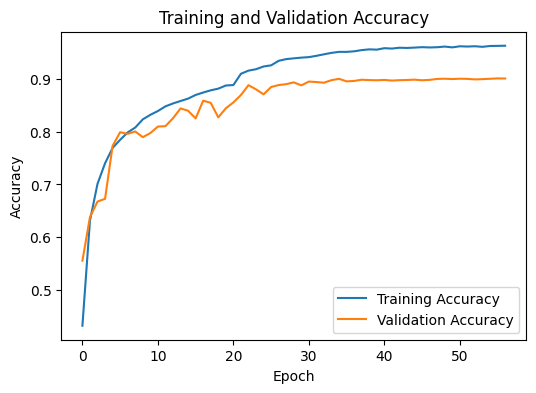

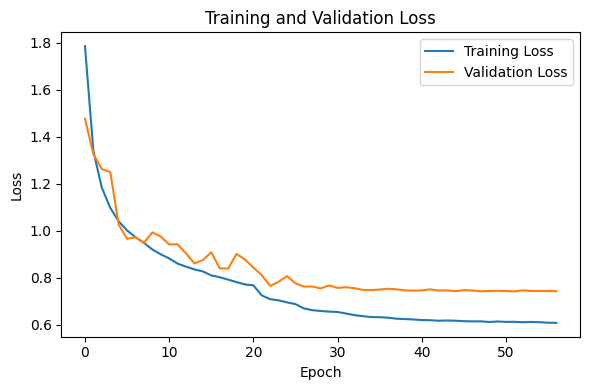

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


=============== Classification Report (CNN) ===============:
              precision    recall  f1-score   support

    airplane       0.91      0.92      0.92      1000
  automobile       0.95      0.97      0.96      1000
        bird       0.87      0.86      0.87      1000
         cat       0.81      0.75      0.78      1000
        deer       0.89      0.90      0.89      1000
         dog       0.88      0.79      0.83      1000
        frog       0.86      0.96      0.91      1000
       horse       0.93      0.93      0.93      1000
        ship       0.94      0.94      0.94      1000
       truck       0.92      0.95      0.94      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



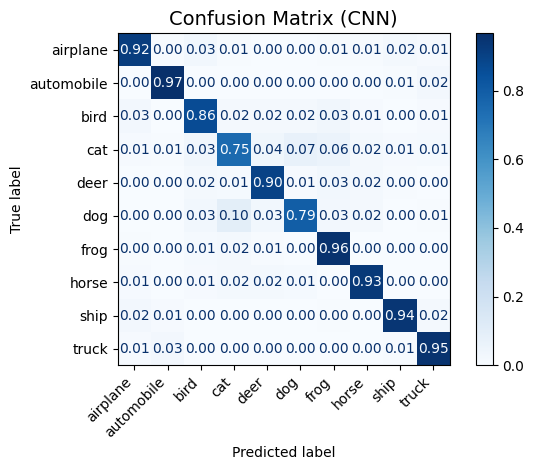

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


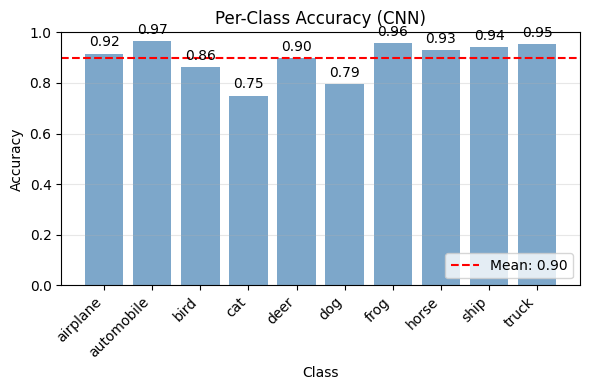

In [ ]:
# Visualizations and results for the 10th model
cnn_plots(history_10)
cnn_results(model_10, x_test, y_test, class_names)
cnn_per_class_accuracy(model_10, x_test, y_test, class_names)